<a href="https://colab.research.google.com/github/77-SP/Financial--Analysis--Phyton--Basics/blob/main/FinanceWithSamyaEpisode_44.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Finance With Samya — Episode 44**
**IPL 2026: Which Team Got the Best ROI?**

 *Series* : Finance With Samya

 *Auother* : Samya Patel

**Concepts Covered:**
- Return on Investment (ROI)
- Capital Allocation Efficiency
- Value Creation


**Data Sources:**
 - Squad spend: cricjosh.in/ipl-2026-salary
- Points table: ESPNcricinfo / Wikipedia (IPL 2026 final standings)


In [99]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# **IPL 2026 Data**

In [100]:
# IPL 2026 Teams
teams = ['RCB', 'GT', 'MI', 'RR', 'DC',
         'PBKS', 'SRH', 'LSG', 'KKR', 'CSK']

# Total squad spend (₹ crore)
spend = [88.7, 84.8, 90.2, 86.3, 86.9,
         92.1, 91.5, 89.6, 87.1, 85.4]

# League stage wins
wins = [9, 9, 7, 7, 6,
        6, 6, 6, 5, 6]

# Playoff bonus
playoff_bonus = [3, 2, 1, 0, 0,
                 1, 0, 0, 0, 0]

# **Create DataFrame**

In [101]:
import pandas as pd
from IPython.core.display import publish_display_data
ipl_df =pd.DataFrame({
    'Team': teams,
    'Spend_Cr': spend,
    'Wins': wins,
    'Playoff_Bonus': playoff_bonus
})

ipl_df

,Team,Spend_Cr,Wins,Playoff_Bonus
0,RCB,88.7,9,3
1,GT,84.8,9,2
2,MI,90.2,7,1
3,RR,86.3,7,0
4,DC,86.9,6,0
5,PBKS,92.1,6,1
6,SRH,91.5,6,0
7,LSG,89.6,6,0
8,KKR,87.1,5,0
9,CSK,85.4,6,0


# **ROI Calculation**

In [102]:
# ROI = Wins per ₹10 crore spent

ipl_df['ROI'] = round(
    (ipl_df['Wins'] / ipl_df['Spend_Cr']) * 10,
    3
)

ipl_df

,Team,Spend_Cr,Wins,Playoff_Bonus,ROI
0,RCB,88.7,9,3,1.015
1,GT,84.8,9,2,1.061
2,MI,90.2,7,1,0.776
3,RR,86.3,7,0,0.811
4,DC,86.9,6,0,0.690
5,PBKS,92.1,6,1,0.651
6,SRH,91.5,6,0,0.656
7,LSG,89.6,6,0,0.670
8,KKR,87.1,5,0,0.574
9,CSK,85.4,6,0,0.703


# **Sort Teams by ROI**

In [103]:
roi_df = ipl_df.sort_values(
    by='ROI',
    ascending=False
).reset_index(drop=True)

roi_df

,Team,Spend_Cr,Wins,Playoff_Bonus,ROI
0,GT,84.8,9,2,1.061
1,RCB,88.7,9,3,1.015
2,RR,86.3,7,0,0.811
3,MI,90.2,7,1,0.776
4,CSK,85.4,6,0,0.703
5,DC,86.9,6,0,0.690
6,LSG,89.6,6,0,0.670
7,SRH,91.5,6,0,0.656
8,PBKS,92.1,6,1,0.651
9,KKR,87.1,5,0,0.574


#**Team Colors**




In [104]:
team_colors = {
    'RCB': '#D41B2C',
    'GT': '#1C4E9D',
    'MI': '#005DA0',
    'RR': '#EA1A85',
    'DC': '#17479E',
    'PBKS': '#DCAB38',
    'SRH': '#F7A721',
    'LSG': '#A2DCFB',
    'KKR': '#3B215E',
    'CSK': '#F9CD05'
}

#**Extract Sorted Variables**

In [105]:
teams_s = roi_df['Team']
roi_s = roi_df['ROI']
spend_s = roi_df['Spend_Cr']
wins_s = roi_df['Wins']

bar_colors = [team_colors[t] for t in teams_s]

#**Create Figure**

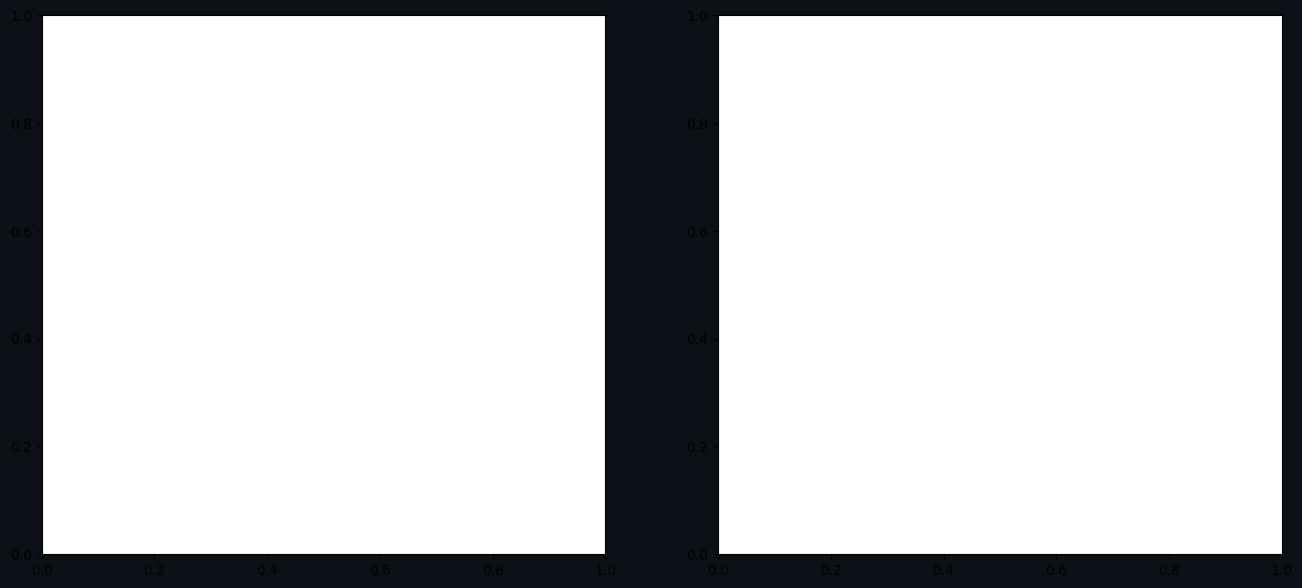

In [106]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7)
)

fig.patch.set_facecolor('#0D1117')

#**ROI Ranking Chart**

In [107]:
ax1 = axes[0]

ax1.set_facecolor('#0D1117')

bars = ax1.barh(
    teams_s,
    roi_s,
    color=bar_colors,
    edgecolor='white',
    linewidth=0.4,
    height=0.6
)

#**Highlight Champion**

In [108]:
for bar, team in zip(bars, teams_s):

    if team == 'RCB':
        bar.set_edgecolor('gold')
        bar.set_linewidth(2)

#**ROI Labels**

In [109]:
for i, (value, team) in enumerate(zip(roi_s, teams_s)):

    trophy = ' 🏆' if team == 'RCB' else ''

    ax1.text(
        value + 0.001,
        i,
        f'{value:.3f}{trophy}',
        va='center',
        ha='left',
        color='white',
        fontsize=9.5,
        fontweight='bold'
    )

#**ROI Chart Formatting**

In [110]:
ax1.set_xlabel(
    'Wins per ₹10 Crore Spent',
    color='#AAAAAA',
    fontsize=11
)

ax1.set_title(
    'IPL 2026 — ROI Ranking\n(Wins per ₹10 Cr of Squad Spend)',
    color='white',
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax1.tick_params(
    colors='white',
    labelsize=10
)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.spines['left'].set_color('#444')
ax1.spines['bottom'].set_color('#444')

ax1.set_xlim(
    0,
    max(roi_s) * 1.2
)

(0.0, 1.2731999999999999)

#**Spend vs Wins Scatter Plot**

In [111]:
ax2 = axes[1]

ax2.set_facecolor('#0D1117')

for team, spend_amt, win_count in zip(
        teams,
        spend,
        wins):

    ax2.scatter(
        spend_amt,
        win_count,
        color=team_colors[team],
        s=220,
        edgecolors='white',
        linewidths=0.8,
        zorder=3
    )

#**Team Labels**

In [112]:
for team, spend_amt, win_count in zip(
        teams,
        spend,
        wins):

    if team == 'RCB':

        ax2.annotate(
            f'{team} 🏆',
            (spend_amt, win_count),
            textcoords='offset points',
            xytext=(8, 6),
            color='gold',
            fontsize=9.5,
            fontweight='bold'
        )

    else:

        ax2.annotate(
            team,
            (spend_amt, win_count),
            textcoords='offset points',
            xytext=(6, 4),
            color='#CCCCCC',
            fontsize=8.5
        )

#**Trend Line**

In [113]:
z = np.polyfit(
    spend,
    wins,
    1
)

trend = np.poly1d(z)

x_line = np.linspace(
    min(spend) - 1,
    max(spend) + 1,
    100
)

ax2.plot(
    x_line,
    trend(x_line),
    '--',
    color='#555',
    linewidth=1.2,
    label='Average Trend',
    zorder=1
)

#**Scatter Plot Formatting**

In [114]:
ax2.set_xlabel(
    'Total Squad Spend (₹ Crore)',
    color='#AAAAAA',
    fontsize=11
)

ax2.set_ylabel(
    'League Stage Wins',
    color='#AAAAAA',
    fontsize=11
)

ax2.set_title(
    'IPL 2026 — Spend vs Performance\n(Does Spending More = Winning More?)',
    color='white',
    fontsize=13,
    fontweight='bold',
    pad=12
)

ax2.tick_params(
    colors='white',
    labelsize=10
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

ax2.spines['left'].set_color('#444')
ax2.spines['bottom'].set_color('#444')

ax2.yaxis.set_major_locator(
    plt.MaxNLocator(integer=True)
)

#**Main Title & Footer**

In [115]:
plt.suptitle(
    'Which IPL 2026 Team Got the Best Return on Investment?',
    color='white',
    fontsize=15,
    fontweight='bold',
    y=1.01
)

fig.text(
    0.5,
    0.01,
    'Finance With Samya | Episode 44 | Data: CricJosh & ESPNcricinfo',
    ha='center',
    color='#555555',
    fontsize=8.5
)

Text(0.5, 0.01, 'Finance With Samya | Episode 44 | Data: CricJosh & ESPNcricinfo')

<Figure size 640x480 with 0 Axes>

#**Outcome**

In [116]:
plt.tight_layout()

plt.savefig(
    'ipl2026_roi_chart.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0D1117'
)

plt.show()

print("Chart saved as ipl2026_roi_chart.png")

<Figure size 640x480 with 0 Axes>

Chart saved as ipl2026_roi_chart.png


In [117]:
if team == 'RCB':
    bar.set_edgecolor('gold')
    bar.set_linewidth(2)

elif team == 'GT':
    bar.set_edgecolor('#00FF7F')
    bar.set_linewidth(2)

In [123]:
if team == 'RCB':
    label = f'{val:.3f} 🏆'

elif team == 'GT':
    label = f'{val:.3f} 📈'

else:
    label = f'{val:.3f}'